# Salary Prediction Using Employee Demographics and Job Attributes (KNN - Regression)

## Problem Statement
 - The objective of this project is to analyze employee-related attributes and develop a machine learning model capable of predicting employee salaries based on professional and demographic characteristics. By identifying the key factors that influence salary levels, organizations can make data-driven compensation decisions and individuals can gain insights into potential earnings based on their career profiles.

# Data Structure
 - The dataset consists of employee workforce information collected from various industries and locations worldwide. It includes details such as job title, years of experience, education level, skills count, industry, company size, work location, remote work status, certifications, and employee salary. The objective is to analyze the factors influencing employee compensation and build a predictive model for salary estimation.
 - Total Rows           : 250000
 - Total Columns        : 10
 - Independent Variables:
1. Job Title
2. Experience Years
3. Education Level
4. Skills Count
5. Industry
6. Company Size
7. Location
8. Remote Work
9. Certifications
 - Target Column        : Salary
 - Problem Type         : Regression Problem
 - Model Used           : KNN Regressor

# Importing Libraries

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Dataset Imported

In [40]:
df=pd.read_csv("job_salary_prediction_dataset.csv")
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


# Data Understanding

In [41]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [42]:
df.tail()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467
249999,Data Analyst,16,Diploma,2,Technology,Medium,UK,No,5,133084


In [43]:
print(f'Number of rows:{df.shape[0]}')
print(f'Number oF columns: {df.shape[1]}')

Number of rows:250000
Number oF columns: 10


In [44]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [45]:
df.describe(include=object)

,job_title,education_level,industry,company_size,location,remote_work
count,250000,250000,250000,250000,250000,250000
unique,12,5,10,5,10,3
top,Backend Developer,Master,Finance,Large,Australia,No
freq,21125,50352,25393,50254,25258,83621


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [47]:
df.dtypes

job_title           object
experience_years     int64
education_level     object
skills_count         int64
industry            object
company_size        object
location            object
remote_work         object
certifications       int64
salary               int64
dtype: object

# Data Quality Check

In [48]:
df.duplicated().sum()

np.int64(0)

In [49]:
df.isna().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

# Exploratory Data Analysis

In [50]:
df.boxplot()

<Axes: >

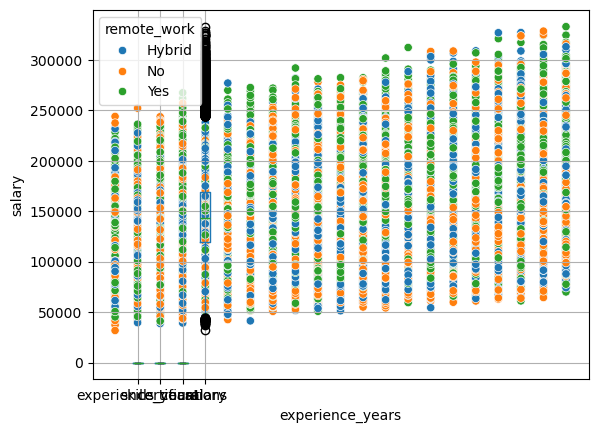

In [51]:
sns.scatterplot(x=df['experience_years'],y=df['salary'],hue=df['remote_work'])
plt.show()

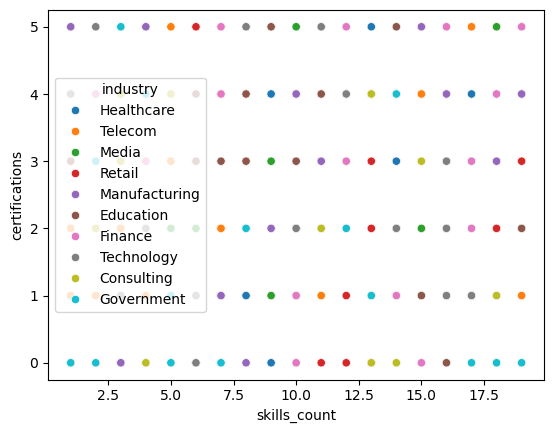

In [52]:
sns.scatterplot(x=df['skills_count'],y=df['certifications'],hue=df['industry'])
plt.show()

# Encoding

In [53]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


## Ordinal Encoding

In [54]:
df.groupby('job_title')['salary'].mean().sort_values(ascending=True)

job_title
Data Analyst                 119891.696603
Business Analyst             122551.231354
Frontend Developer           132653.842485
Backend Developer            139202.768663
Software Engineer            141739.521460
Data Scientist               147258.214409
Cybersecurity Analyst        148697.695548
DevOps Engineer              149959.266791
Cloud Engineer               152102.535290
Product Manager              157594.932029
Machine Learning Engineer    163022.504570
AI Engineer                  173498.480640
Name: salary, dtype: float64

In [55]:
df['job_title']=df['job_title'].map({
    'Data Analyst':0,
    'Business Analyst':1,
    'Frontend Developer':2,
    'Backend Developer':3,
    'Software Engineer':4,
    'Data Scientist':5,
    'Cybersecurity Analyst':6,
    'DevOps Engineer':7,
    'Cloud Engineer':8,
    'Product Manager':9,
    'Machine Learning Engineer':10,
    'AI Engineer':11

})

In [56]:
# Average salary by location
df.groupby('location')['salary'].mean().sort_values(ascending=True)



location
India           97690.402249
Netherlands    139294.813644
Singapore      139340.696625
Australia      139362.150804
Sweden         139440.637291
Remote         139442.525155
Germany        153376.211000
UK             160075.143018
Canada         167391.273396
USA            181716.303919
Name: salary, dtype: float64

In [57]:
df['location']=df['location'].map({
    'India':0,
    'Netherlands':1,
    'Singapore':2,
    'Australia':3,
    'Sweden':4,
    'Remote':5,
    'Germany':6,
    'UK':7,
    'Canada':8,
    'USA':9
})

In [58]:
df.drop(columns='industry',inplace=True)

In [59]:
df['education_level']=df['education_level'].map({
    'High School':0,
    'Diploma':1,
    'Bachelor':2,
    'Master':3,
    'PhD':4
})

In [60]:
df['company_size']=df['company_size'].map({
    'Startup': 0,
    'Small': 1,
    'Medium': 2,
    'Large': 3,
    'Enterprise': 4
})

In [61]:
df['remote_work']=df['remote_work'].map({
    'No': 0,
    'Hybrid': 1,
    'Yes': 2
})

In [62]:
df.head()

,job_title,experience_years,education_level,skills_count,company_size,location,remote_work,certifications,salary
0,11,10,2,2,2,0,1,2,109413
1,0,5,2,17,1,3,0,0,93764
2,2,18,4,4,2,2,0,1,148123
3,1,19,4,13,2,8,2,0,189123
4,9,15,2,7,3,4,2,0,165069


# Defining X and y

In [63]:
X=df.drop(columns='salary')
y=df['salary']

# Scaling For X

In [64]:
si=StandardScaler()
scaled_data=si.fit_transform(df)
scaled_data

array([[ 1.59341839e+00, -8.92322321e-04, -4.52631678e-04, ...,
         3.51899550e-03, -2.88271936e-01, -9.70519649e-01],
       [-1.59671989e+00, -8.25894468e-01, -4.52631678e-04, ...,
        -1.22175799e+00, -1.46028059e+00, -1.38885399e+00],
       [-1.01669475e+00,  1.31911111e+00,  1.41402136e+00, ...,
        -1.22175799e+00, -8.74276261e-01,  6.42891180e-02],
       ...,
       [-1.30670732e+00, -1.48589618e+00, -4.52631678e-04, ...,
         1.22879598e+00, -1.46028059e+00, -1.86404801e+00],
       [-1.46657037e-01, -1.65089661e+00, -1.41492663e+00, ...,
         3.51899550e-03,  1.46974104e+00, -1.47699051e+00],
       [-1.59671989e+00,  9.89110253e-01, -7.07689629e-01, ...,
        -1.22175799e+00,  1.46974104e+00, -3.37738499e-01]],
      shape=(250000, 9))

# Train-Test Split

In [65]:
x_train,x_test,y_train,y_test=train_test_split(scaled_data,y,test_size=0.3,random_state=42)

# Finding  best-K values

In [66]:
train_accuracy=[]
test_accuracy=[]
for i in range(2,20):
    kn=KNeighborsRegressor(n_neighbors=i)
    kn.fit(x_train,y_train)
    train_accuracy.append(kn.score(x_train,y_train))
    test_accuracy.append(kn.score(x_test,y_test))

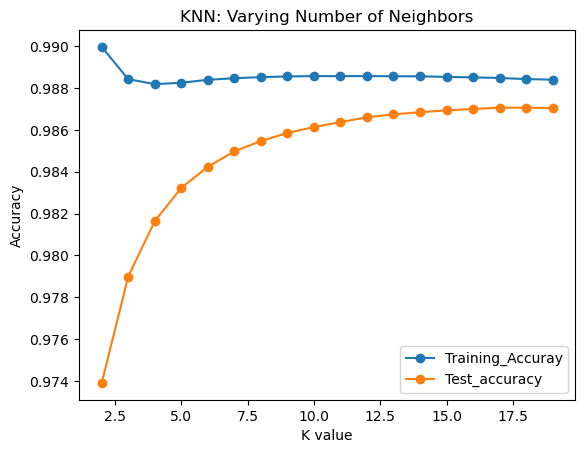

In [67]:
plt.plot(range(2,20),train_accuracy,label='Training_Accuray',marker='o')
plt.plot(range(2,20),test_accuracy,label='Test_accuracy',marker='o')
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.title('KNN: Varying Number of Neighbors')
plt.legend()
plt.show()

# Final Model Building

In [68]:
kn=KNeighborsRegressor(n_neighbors=13)
kn.fit(x_train,y_train)
y_pred=kn.predict(x_test)
y_pred

array([164627.69230769,  90691.76923077,  75209.69230769, ...,
       130271.30769231, 198116.07692308, 160184.        ], shape=(75000,))

# Evaluation

In [69]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print(f'Mean_squared_error: {mse}')
print(f'Root_mean_squared_error: {np.sqrt(mse)}')
print(f'Mean_absolute_error: {mae}')
print(f'R2_score: {r2_score(y_test,y_pred)}')

Mean_squared_error: 18480860.41970438
Root_mean_squared_error: 4298.937126744747
Mean_absolute_error: 3385.8443682051284
R2_score: 0.9867384093418782


In [70]:
print(f'Traning Accuracy: {kn.score(x_train,y_train)}')
print(f'Testing Accuracy: {kn.score(x_test,y_test)}')

Traning Accuracy: 0.9885595127288519
Testing Accuracy: 0.9867384093418782


# Conclusion

The K-Nearest Neighbors (KNN) Regression model was successfully trained to predict employee salaries based on factors such as job title, experience, education level, skills count, industry, company size, location, remote work status, and certifications.

The model achieved a **training R² score of 98.86%** and a **testing R² score of 98.67%**, indicating that it explains nearly all the variance in employee salaries and generalizes well to unseen data. The small difference between training and testing accuracy suggests that the model is neither overfitting nor underfitting.

The performance metrics further validate the model's effectiveness:

* **Mean Squared Error (MSE):** 18,480,860.42
* **Root Mean Squared Error (RMSE):** 4,298.94
* **Mean Absolute Error (MAE):** 3,385.84

These error values indicate that the predicted salaries are, on average, very close to the actual salaries. Overall, the KNN Regressor demonstrates excellent predictive performance and can be considered a reliable model for employee salary estimation.

**Final Result:** The KNN Regression model achieved an **R² Score of 98.67%**, making it highly effective for predicting employee salaries based on workforce and employment-related attributes. ✅
